# Unidad 1 · Actividad 2
# Laboratorio 1: Pipeline de preprocesamiento para datos secuenciales

## Proyecto: Clasificación de sentimiento en reseñas de usuarios


**Dataset:** [Amazon Fine Food Reviews](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews) (Kaggle).

---

### Tabla de contenido

1. Objetivo y alcance
2. Carga y documentación del dataset
3. Limpieza y preparación
4. Variable objetivo
5. División Train / Validation / Test
6. Preparación del texto
7. Tokenización y vocabulario
8. Longitud, padding y truncamiento
9. Generación de secuencias
10. Validación de las secuencias
11. Salida preparada para entrenamiento
12. Guardado y reproducibilidad
13. Conclusiones y limitaciones
14. Referencias

## 1. Objetivo y alcance

El objetivo es construir un **pipeline reproducible de preprocesamiento** que transforme
reseñas de texto libre en secuencias numéricas, listas para alimentar
un modelo secuencial de clasificación de sentimiento.

### 1.1 Definición de las variables

| Variable | Rol |
| :--- | :--- |
| `Text` | Texto original de la reseña. Será la fuente de la entrada del modelo. |
| `Text_clean` | Versión limpia y normalizada de `Text`. Es la que se tokeniza y se convierte en secuencia. |
| `Score` | Calificación original del usuario (1–5). **No entra como predictor**; se usa solo para derivar la etiqueta. |
| `Sentimiento` | Variable objetivo (**y**): Negativo (1–2), Neutral (3), Positivo (4–5). |
| `Time` | Marca temporal. Se usa para definir la partición cronológica, no como característica del modelo. |

Flujo previsto:

```
Text -> limpieza -> Text_clean -> tokenización -> índices -> padding/truncamiento -> X
Score -> mapeo -> Sentimiento -> codificación -> y
```

## 2. Carga y documentación del dataset

### 2.1 Librerías y configuración global

Se emplean únicamente librerías Comunes tales como (`pandas`, `numpy`, `matplotlib`). La tokenización se implementa con `re` y `collections.Counter`, el índice de vocabulario generado (0 = padding,
1 = token desconocido).

In [1]:
import os
import re
import io
import json
import random
import sys
import kagglehub

from collections import Counter
from pathlib import Path
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Parámetros del pipeline (se justifican en las secciones 5, 7 y 8)
PROP_TRAIN, PROP_VAL = 0.70, 0.15   # ver sección 5
VOCAB_SIZE = None                    # se decide con evidencia en la sección 7
MAX_LEN = None                       # se decide con evidencia en la sección 8
PAD_TOKEN, OOV_TOKEN = '<PAD>', '<OOV>'
MAPEO_SENTIMIENTO = {'Negativo': 0, 'Neutral': 1, 'Positivo': 2}

### 2.2 Carga del dataset

In [2]:
#Cargamos el dataset de Kaggle
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
print("Path to dataset files:", path)

#definimos el dataset
ruta_df = '/kaggle/input/amazon-fine-food-reviews/Reviews.csv'
df = pd.read_csv(ruta_df)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-fine-food-reviews


In [3]:
# Tmaño base del dataframe
print(df.shape)

(568454, 10)


### 2.3 Estructura y diccionario de variables

| Variable | Descripción |
| :--- | :--- |
| **Id** | Identificador único por fila |
| **ProductId** | Identificador único por producto |
| **UserId** | Identificador único por usuario |
| **ProfileName** | Nombre del perfil del usuario |
| **HelpfulnessNumerator** | Usuarios que indicaron si la reseña les resultó útil |
| **HelpfulnessDenominator** | Usuarios que indicaron si la reseña les resultó útil o no |
| **Score** | Calificación del producto (escala 1–5) |
| **Time** | Marca de tiempo (Unix) de la reseña |
| **Summary** | Resumen breve de la reseña |
| **Text** | Texto completo de la reseña |

In [4]:
df.head(3)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [5]:
print('Dimensiones (filas, columnas):', df.shape)
df.info()

Dimensiones (filas, columnas): (568454, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


El conjunto contiene 568.454 reseñas y 10 variables. `Text` aporta la secuencia de entrada,
`Score` la fuente de la etiqueta y `Time` la referencia temporal para la partición.

In [6]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


Del `df.describe()` podemos observar los siguientes comportamientos del dataset que toca a tener en cuenta:

- Time : Esta en formato UNIX, toca aplicar transformaciones para que esta quede en un formato mas legible y operable por ejemplo: (dd-mm-yyyy).
- Score : El promedio esta en 4.18 mientras que en el primer percentil, ya podemos observar que estos inician desde 4, esto importa ya que nos podemos estar enfrentando a un desbalance de clases extremo, donde no nos conviene contar con reseñas mayormente positivas para que el modelo pueda generalizar bien todas las categorias de las reseñas.
- Helpfulness : Ambas columnas cuentan en promedio con pocos usuarios que creen que les resulto util, podemos ver como hasta en el tercer cuartil, estos llegan al 2, por lo que podria generar inconvenientes ya que el maximo llega hasta 866 y 923 respectivamente, por lo que podriamos tener con varios outliers (no significa que sean datos invalidos) pero puede que las demas reseñas al no contar con mucha interaccion por parte de los usuarios, al momento de entrenar el modelo estas columnas no aporten mucha informacion.

## 3. Limpieza y preparación

Esta sección ejecuta las decisiones de limpieza. Se documenta, en cada paso, el número de
registros antes y después de la operación.

### 3.1 Valores faltantes

Se verifica la disponibilidad de las variables que efectivamente intervienen en el pipeline
(`Text`, `Score` y `Time`) antes de aplicar cualquier eliminación.

In [7]:
print('Valores faltantes por columna:')
display(df.isnull().sum())

print('Valores de Score fuera del rango 1-5:',
      int((~df['Score'].isin([1, 2, 3, 4, 5])).sum()))

Valores faltantes por columna:


,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


Valores de Score fuera del rango 1-5: 0


**Decisión.** Las variables más relevantes para nosotros (`Text`, `Score`, `Time`) no presentan valores faltantes, aun faltaria revisar los valores unicos dentro de estas columnas para poder decidir la calidad de los datos<br><br> Podemos observar como contamos con casi el 100% del dataframe completo, solo contamos con 26 nulos en la columna `ProfileName` y 27 nulos en la columna `Summary`, aun que toca ver los valores unicos en el dataframe, ya que puede que encontremos valores como los siguientes: ('NA','nan','','.') entre otros.

### 3.2 Registros duplicados

El diagnóstico previo identificó 174.875 reseñas con texto repetido. Antes de eliminar nada se
distingue entre **redundancia** (mismo texto con la misma etiqueta) y **conflicto de etiqueta**
(mismo texto asociado a sentimientos distintos), porque ambos casos exigen tratamientos
diferentes.

La función de mapeo `Score -> Sentimiento` se anticipa aquí únicamente para cuantificar los
conflictos. Más adelante se realiza en la sección 4 la formalización.

In [8]:
df['Score'].unique()

array([5, 1, 4, 2, 3])

In [9]:
cambios_score = {
    1:'Negativo',
    2:'Negativo',
    3:'Neutro',
    4:'Positivo',
    5:'Positivo',
}
df['Score_cat'] = df['Score'].replace(cambios_score)

In [10]:
df['Score_cat'].unique()

array(['Positivo', 'Negativo', 'Neutro'], dtype=object)

In [11]:
print('Numero de valores unicos en cada columna')
columnas = df.columns.tolist()
for columna in columnas:
  print('Nombre de la columna: ',columna)
  print('Numero de valores unicos',df[columna].nunique())
  print('\n')

Numero de valores unicos en cada columna
Nombre de la columna:  Id
Numero de valores unicos 568454


Nombre de la columna:  ProductId
Numero de valores unicos 74258


Nombre de la columna:  UserId
Numero de valores unicos 256059


Nombre de la columna:  ProfileName
Numero de valores unicos 218415


Nombre de la columna:  HelpfulnessNumerator
Numero de valores unicos 231


Nombre de la columna:  HelpfulnessDenominator
Numero de valores unicos 234


Nombre de la columna:  Score
Numero de valores unicos 5


Nombre de la columna:  Time
Numero de valores unicos 3168


Nombre de la columna:  Summary
Numero de valores unicos 295742


Nombre de la columna:  Text
Numero de valores unicos 393579


Nombre de la columna:  Score_cat
Numero de valores unicos 3




Aqui podemos observar y concluir lo siguiente de los datos:
- `Id`, todos los valores son unicos, esto es de esperar, da a entender que la estructura o la llave primaria no tiene valores irregulares
- `ProductId`, podemos ver como las reseñas provienen de 74258 productos diferentes
- `UserId` y `ProfileName`, podemos ver como contamos con mas user id que con nombres de perfil, podemos concluir que varias personas diferentes comparten nombre de perfil, esto al ser nombres suele ser comun, pues personas diferentes pueden compartir el mismo nombre, ej (Juan - hay varios Juan, pero el UserId es quien los reconoce por aparte)
- `Text`, podemos ver como de los 568454 registros que tenemos, solo 393579 son unicos, dando a entender que podemos encontrarnos con reseñas sencillas, que muchas personas tienden a formular, como lo es por ejemploi ('Excelente', 'Bastante recomendado', 'Mala calidad', etc...)

In [12]:
print('Numero de filas duplicadas: ',df.duplicated().sum())
columnas = df.columns.tolist()
for columna in columnas:
  print('Nombre de la columna: ',columna)
  print('Numero de duplicados en ',columna)
  print(df[columna].duplicated().sum())
  print('\n')

Numero de filas duplicadas:  0
Nombre de la columna:  Id
Numero de duplicados en  Id
0


Nombre de la columna:  ProductId
Numero de duplicados en  ProductId
494196


Nombre de la columna:  UserId
Numero de duplicados en  UserId
312395


Nombre de la columna:  ProfileName
Numero de duplicados en  ProfileName
350038


Nombre de la columna:  HelpfulnessNumerator
Numero de duplicados en  HelpfulnessNumerator
568223


Nombre de la columna:  HelpfulnessDenominator
Numero de duplicados en  HelpfulnessDenominator
568220


Nombre de la columna:  Score
Numero de duplicados en  Score
568449


Nombre de la columna:  Time
Numero de duplicados en  Time
565286


Nombre de la columna:  Summary
Numero de duplicados en  Summary
272711


Nombre de la columna:  Text
Numero de duplicados en  Text
174875


Nombre de la columna:  Score_cat
Numero de duplicados en  Score_cat
568451




In [13]:
print('Filas con Text + Score repetidos: ',(df.duplicated(subset=['Text', 'Score']).sum()))

Filas con Text + Score repetidos:  174779


Podemos ver que hay duplicados en cada columna:
- `UserId`, es razonable ya que un usuario puede realizar varias compras y dejar una reseña en cada compra distina.
- `ProductId`, tambien es razonable ya que indica que varios usuarios que compraron el mismo item dejaron su reseña sobre el mismo producto
- `Text`, esta no cuadra mucho ya que hay 174875 duplicados en la variable, puede ser que hay varias reseñas generales, que muchos usuarios ponen como lo seria por ejemplo 'Excelente' o 'Malo', ya que en reseñas mas elaboradas es mas dificil que varios usuarios lleguen a escribir la misma reseña termino por termino`


Antes de tomar alguna decision, vamos a limpiar las reseñas, dejandolas en un formato limpio y poder volver a comparar y tomar decisiones con mas fundamento.

### 3.3 Limpieza del texto

Realizamos una limpieza basica, con el fin de primero comprender la naturaleza de los registros duplicados, tras varios metodos de revision, se identifico lo siguiente:
- Se presentan aproximadamente 175.000 registros que comparten el siguiente comportamiento: (Mismo UserId, mismo Text, Time muy similar (no hay varios minutos de diferencia), pero cuenta con diferentes ProductId), tras realizar una investigacion del dataset, encontramos que este patron es tipico en los datasets de Amazon, ya que la mayoria de productos cuentan con variantes similares, que es lo que hace Amazon, esta no separa reseña de cada usuario por el producto que adquirio, si no que este duplica la reseña del usuario que compro el producto 100, y los duplica en las variantes del mismo producto con ProductId 101, 102, etc... ingresando en este caso, casi el 30% del dataset cuenta con este comportamiento.<br><br>
**Que optamos por realizar:** En terminos breves, eliminamos las reseñas que comparten este comportamiento, pero mantuvimos la reseña mas antigua, que lo mas probable es que sea la original, el producto que si adquirio el usuario, no sus variantes.

- Encontramos otras situaciones, donde se repite el Text pero cuenta con UserId diferentes y Score diferente (16 grupos duplicados - cada grupo cuenta en promedio 4 registros, osea 64 regristros que cuentan con este comportamiento), estos datos tambien decidimos eliminarlos, manteniendo el mas antiguo, por que, a pesar de que sean registros validos, en el contexto del objetivo de implementar un clasificador de sentimiento, si ingresamos al modelo, mismas reseñas pero con un score diferente, esta se va a confundir, no va a generalizar.

- Otro comportamiento que encontramos es el siguiente: (Varios autores, mismo score) no son varios los registros, apx 80, pero son datos redundantes, en donde puede generar data leakage, por lo que tambien se optaron por eliminarse.

- Finalmente, encontramos 428 registros con el mismo texto pero con Score diferente, esto tambien puede llegar a confundir el modelo, por lo que se optaron por eliminarse.

In [14]:
# el objetivo es eliminar valores que no aportan valor para el analisis de las reseñas
df["_key"] = (df["Text"].astype(str)
                .str.lower()
                .str.replace(r"<[^>]+>", " ", regex=True)
                .str.replace(r"\s+", " ", regex=True)
                .str.strip())

g = df.groupby("_key")
perfil = pd.DataFrame({
    "n_filas":     g.size(),
    "n_usuarios":  g["UserId"].nunique(),
    "n_productos": g["ProductId"].nunique(),
    "n_scores":    g["Score"].nunique(),
    "n_tiempos":   g["Time"].nunique(),
})
dups = perfil[perfil["n_filas"] > 1]

print(f"Filas totales:        {len(df):,}")
print(f"Textos únicos:        {len(perfil):,}")
print(f"Filas redundantes:    {len(df) - len(perfil):,} "
      f"({1 - len(perfil)/len(df):.1%})")
print(f"Grupos duplicados:    {len(dups):,}")

Filas totales:        568,454
Textos únicos:        393,121
Filas redundantes:    175,333 (30.8%)
Grupos duplicados:    58,247


In [15]:
def tipo(r):
    if r.n_usuarios == 1 and r.n_productos == 1:  return "1. Reenvío exacto"
    if r.n_usuarios == 1 and r.n_productos > 1:   return "2. Mismo autor, varios productos"
    if r.n_usuarios > 1  and r.n_scores == 1:     return "3. Varios autores, mismo score"
    return "4. Varios autores, SCORES DISTINTOS"

dups = dups.assign(tipo=dups.apply(tipo, axis=1))
print(dups["tipo"].value_counts())
print("\nGrupos con score contradictorio:", (dups["n_scores"] > 1).sum())
print("Filas afectadas:", dups.loc[dups["n_scores"] > 1, "n_filas"].sum())

tipo
2. Mismo autor, varios productos       58162
1. Reenvío exacto                         40
3. Varios autores, mismo score            29
4. Varios autores, SCORES DISTINTOS       16
Name: count, dtype: int64

Grupos con score contradictorio: 119
Filas afectadas: 428


In [16]:
# Inspecciona los casos contradictorios
conflict = dups[dups["n_scores"] > 1].sort_values("n_filas", ascending=False)
for k in conflict.head(3).index:
    sub = df[df["_key"] == k]
    print(f"\nScores: {sorted(sub.Score.unique())} | usuarios: {sub.UserId.nunique()}")
    print(k[:200], "...")


Scores: [np.int64(4), np.int64(5)] | usuarios: 1
our westies love the caesar canine cuisine foods, they seem to prefer the pates to the sauced varieties, but they eat all of them. i like to give them a big variety of flavors and caesar's food comes  ...

Scores: [np.int64(3), np.int64(4)] | usuarios: 1
the caribou blend k cups have fulfilled our household's need for a plain old cup of coffee in the morning that isn't anything fancy, but still gets the job done. we were searching for a blend that was ...

Scores: [np.int64(2), np.int64(3)] | usuarios: 1
even though these are in sealed, individual packages, which is nice, it seems like they don't retain there freshness. a few of the sticks got like shoe leather and had little taste. i would not purcha ...


In [17]:
ej = dups[dups.tipo == "2. Mismo autor, varios productos"].nlargest(1, "n_filas").index[0]
sub = df[df["_key"] == ej]
print(f"{len(sub)} filas | usuario: {sub.UserId.iloc[0]} | scores: {sub.Score.unique()}")
print(sub[["ProductId", "Score", "Time"]].to_string(index=False))
print("\nTexto:", ej[:250])

199 filas | usuario: A3TVZM3ZIXG8YW | scores: [1]
 ProductId  Score       Time
B0002TJAZK      1 1291420800
B0002TJAZK      1 1291420800
B00106TG9Y      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B003ANFMY8      1 1291420800
B009GHI6I6      1 1291420800
B009GHI6I6      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B003WK0D8O      1 1291420800
B0002MLA5K      1 1291420800
B0002MLA5K      1 1291420800
B0002MLA5K      1 1291420800
B0002MLA5K      1 1291420800
B0002MLA5K      1 1291420800
B0002MLA5K      1 1291420800
B0002MLA5K      1 1291

Usuario: A3TVZM3ZIXG8YW
Podemos ver como 199 filas tiene el mismo score y una fecha identica, pero el ProductId es diferente, por lo que comprueba la estructura de reseñas que maneja Amazon.

In [18]:
n_inicial = len(df)   # registros antes de la desduplicación (se reutiliza en las secciones 12 y 13)
print('Registros antes de la desduplicación:', n_inicial)

Registros antes de la desduplicación: 568454


In [19]:
df = (df.sort_values("Time")
        .drop_duplicates("_key", keep="first")
        .drop(columns="_key")
        .reset_index(drop=True))

In [20]:
print('Registros despues de eliminar las filas redundantes: ',len(df))

Registros despues de eliminar las filas redundantes:  393121


In [21]:
df_clean = df.copy()

### 3.4 Normalización del texto (`Text_clean`)

La desduplicación anterior se apoyó en una clave auxiliar (`_key`) que se descartó al terminar el
paso. El pipeline necesita, en cambio, una columna estable con el texto ya normalizado: es la que
se tokeniza en la sección 6 y la que se convierte en secuencias en la sección 9. Esa columna es
`Text_clean` y se construye aquí sobre `df_clean`, dejando `Text` intacto para poder auditar en
cualquier momento el efecto de la transformación.

La normalización es **conservadora**: retira lo que no es lenguaje del usuario, sin tocar aquello
que el modelo secuencial necesita aprender.

| Operación | Justificación |
| :--- | :--- |
| Decodificación de entidades HTML (`&amp;`, `&quot;`) | El corpus se extrajo de una página web y arrastra entidades codificadas que no son palabras. |
| Eliminación de etiquetas HTML (`<br />`, `<a href=...>`) | Es marcado de presentación, no contenido de la reseña. |
| Sustitución de URLs | Cada dirección es un token distinto que infla el vocabulario sin aportar sentimiento. |
| Conversión a minúsculas | Evita que `Good` y `good` ocupen dos posiciones distintas del índice. |
| Normalización de espacios | Homogeniza la separación entre tokens después de las sustituciones anteriores. |

**No** se aplican stemming, lematización ni eliminación de *stopwords*. En clasificación de
sentimiento con modelos secuenciales, partículas como `not`, `but` o `very` cambian por completo
la polaridad de una frase, y el orden de las palabras es justamente parte de lo que el modelo debe
aprender. La puntuación se conserva en `Text_clean`; es la tokenización de la sección 6 la que
decide qué hacer con ella.

Esta normalización es más estricta que la clave `_key` usada en la sección 3.3, que no decodificaba
entidades ni retiraba URLs. Por eso pueden aparecer duplicados residuales y textos que se quedan
sin contenido: ambos casos se cuantifican antes de decidir.

In [22]:
import html

RE_HTML = re.compile(r'<[^>]+>')
RE_URL = re.compile(r'http\S+|www\.\S+')
RE_ESPACIOS = re.compile(r'\s+')

def limpiar_texto(texto):
    """Normalización conservadora de una reseña.

    Decodifica entidades HTML, retira marcado y direcciones web, pasa a minúsculas y
    homogeniza los espacios. No altera el orden de las palabras ni la puntuación.
    """
    t = html.unescape(str(texto))     # entidades HTML -> caracteres
    t = RE_HTML.sub(' ', t)           # etiquetas <br />, <a href=...>
    t = RE_URL.sub(' ', t)            # direcciones web
    t = t.lower()                     # minúsculas
    return RE_ESPACIOS.sub(' ', t).strip()

df_clean['Text_clean'] = df_clean['Text'].map(limpiar_texto)

n_antes_norm = len(df_clean)
sin_contenido = ~df_clean['Text_clean'].str.contains(r'[a-z0-9]', regex=True)

print('Registros antes de la normalización     :', n_antes_norm)
print('Textos vacíos tras la normalización     :', int((df_clean['Text_clean'].str.len() == 0).sum()))
print('Textos sin ningún carácter alfanumérico :', int(sin_contenido.sum()))
print('Duplicados que emergen tras normalizar  :', int(df_clean.duplicated(subset=['Text_clean']).sum()))

Registros antes de la normalización     : 393121
Textos vacíos tras la normalización     : 0
Textos sin ningún carácter alfanumérico : 1
Duplicados que emergen tras normalizar  : 1


**Decisión.** Se aplican dos filtros, coherentes con el criterio ya adoptado en la sección 3.3:

1. Los duplicados que emergen tras normalizar son reseñas que solo se diferenciaban en entidades
   HTML, direcciones web o mayúsculas. Para el modelo son la misma observación, así que se conserva
   **una sola ocurrencia, la más antigua** (`sort_values('Time')` + `keep='first'`), exactamente el
   mismo criterio que se usó al eliminar las reseñas replicadas entre variantes de producto.
2. Los textos que quedan sin ningún carácter alfanumérico no producirían ningún token con el
   esquema de la sección 6: generarían una secuencia enteramente de relleno, es decir, una fila sin
   información pero con etiqueta. Se descartan.

Ambos filtros se aplican **antes** de la partición (sección 5), de modo que una misma reseña no
pueda quedar simultáneamente en entrenamiento y en prueba.

In [23]:
df_clean = (df_clean[(df_clean['Text_clean'].str.len() > 0) & ~sin_contenido]
            .sort_values('Time')
            .drop_duplicates(subset=['Text_clean'], keep='first')
            .reset_index(drop=True))

print('Registros tras la normalización del texto  :', len(df_clean))
print('Eliminados en este paso                    :', n_antes_norm - len(df_clean))
print('Total eliminado frente al dataset original :', n_inicial - len(df_clean),
      f'({(n_inicial - len(df_clean)) / n_inicial * 100:.2f} %)')

Registros tras la normalización del texto  : 393119
Eliminados en este paso                    : 2
Total eliminado frente al dataset original : 175335 (30.84 %)


#### Ejemplos de la transformación

Se contrastan tres reseñas que contienen marcado HTML, para hacer visible el efecto de la limpieza
sobre el texto real del corpus.

In [24]:
ejemplos = df_clean[df_clean['Text'].str.contains('<br', regex=False)].head(3)

for k, fila in enumerate(ejemplos.itertuples(), start=1):
    print(f'--- Ejemplo {k} ---')
    print('ORIGINAL :', fila.Text[:220].replace('\n', ' '))
    print('LIMPIO   :', fila.Text_clean[:220])
    print()

--- Ejemplo 1 ---
ORIGINAL : Simply put: Beetlejuice is the funniest comedy of its kind since Ghostbusters.<br />  Michael Keaton plays the title character, a fun-loving ghost that likes to do mischief.  Beetlejuice is called by a couple (Davis and 
LIMPIO   : simply put: beetlejuice is the funniest comedy of its kind since ghostbusters. michael keaton plays the title character, a fun-loving ghost that likes to do mischief. beetlejuice is called by a couple (davis and baldwin)

--- Ejemplo 2 ---
ORIGINAL : Long live Camper Van Beethoven!! This is a blessing for long time CVB fans who didn't have a chance to upgrade their collection to CD before most of this went out of print.  Wow, where to begin?  CVB was a band that matu
LIMPIO   : long live camper van beethoven!! this is a blessing for long time cvb fans who didn't have a chance to upgrade their collection to cd before most of this went out of print. wow, where to begin? cvb was a band that mature

--- Ejemplo 3 ---
ORIGINAL : I hav

## 4. Variable objetivo

La etiqueta del proyecto es `Sentimiento`, derivada de `Score` con la regla ya definida
(1–2 -> Negativo, 3 -> Neutral, 4–5 -> Positivo). `Score` queda excluido de la entrada del modelo
y se conserva solo como fuente de la etiqueta.

### 4.1 Formalización de la regla

En la sección 3.2 el mapeo se anticipó con la columna auxiliar `Score_cat`, cuyo único propósito
era cuantificar los conflictos de etiqueta entre reseñas duplicadas. Aquí la regla se formaliza en
una función explícita aplicada sobre `Score`, por tres motivos:

- la etiqueta queda derivada de una única fuente documentada (`Score`) y no de una columna
  intermedia, lo que hace el paso reproducible y auditable;
- unifica el nombre de la clase central con el diccionario `MAPEO_SENTIMIENTO` de la sección 2.1,
  que la llama `Neutral` mientras que `Score_cat` la llamaba `Neutro`. Sin esa unificación, la
  codificación numérica de la sección 9.1 devolvería nulos para toda la clase;
- permite contrastar ambas construcciones y dejar la verificación impresa en el notebook.

In [25]:
def mapear_sentimiento(score):
    """Regla de negocio del proyecto: 1-2 -> Negativo, 3 -> Neutral, 4-5 -> Positivo."""
    if score <= 2:
        return 'Negativo'
    if score == 3:
        return 'Neutral'
    return 'Positivo'

df_clean['Sentimiento'] = df_clean['Score'].map(mapear_sentimiento)

# Contraste con la etiqueta preliminar de la sección 3.2 (Score_cat nombraba 'Neutro' a la clase 3)
equivalencia = {'Negativo': 'Negativo', 'Neutro': 'Neutral', 'Positivo': 'Positivo'}
coincide = bool((df_clean['Score_cat'].map(equivalencia) == df_clean['Sentimiento']).all())
print('Sentimiento coincide con Score_cat en todos los registros:', coincide)

# Verificación de la regla de mapeo
verificacion = (df_clean.groupby('Sentimiento')['Score']
                .agg(['min', 'max', 'count'])
                .rename(columns={'min': 'Score_min', 'max': 'Score_max', 'count': 'Registros'}))
print('\nVerificación de la regla Score -> Sentimiento:')
display(verificacion)

conteo = df_clean['Sentimiento'].value_counts()
porcentaje = (df_clean['Sentimiento'].value_counts(normalize=True) * 100).round(2)
distribucion = pd.DataFrame({'Registros': conteo, 'Porcentaje': porcentaje})
print('Distribución de la variable objetivo:')
display(distribucion)

Sentimiento coincide con Score_cat en todos los registros: True

Verificación de la regla Score -> Sentimiento:


,Score_min,Score_max,Registros
Sentimiento,,,
Negativo,1,2,56979
Neutral,3,3,29723
Positivo,4,5,306417


Distribución de la variable objetivo:


,Registros,Porcentaje
Sentimiento,,
Positivo,306417,77.95
Negativo,56979,14.49
Neutral,29723,7.56


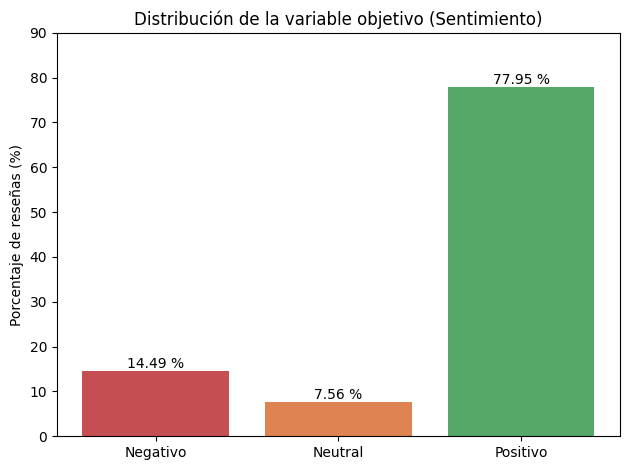

In [26]:
orden = ['Negativo', 'Neutral', 'Positivo']
fig, ax = plt.subplots()
barras = ax.bar(orden, [porcentaje[c] for c in orden],
                color=['#c44e52', '#dd8452', '#55a868'])
ax.bar_label(barras, fmt='%.2f %%')
ax.set_title('Distribución de la variable objetivo (Sentimiento)')
ax.set_ylabel('Porcentaje de reseñas (%)')
ax.set_ylim(0, 90)
plt.tight_layout()
plt.show()

**Desbalance.** La clase Positivo concentra cerca del 78 % de los registros, frente a un 14 %
de Negativo y un 8 % de Neutral. La proporción es prácticamente idéntica a la del dataset
original (78,07 / 14,43 / 7,50 %), lo que confirma que la desduplicación no alteró la estructura
del problema.

El desbalance se documenta aquí como característica del corpus y **no se corrige en esta
etapa**: cualquier remuestreo o ponderación es una decisión de entrenamiento que debe aplicarse
solo sobre el conjunto de entrenamiento, una vez definida la partición y la arquitectura.

## 5. División Train / Validation / Test

### 5.1 Viabilidad de una partición cronológica

El dataset incluye marca temporal, por lo que se evalúa una partición cronológica
(datos antiguos -> entrenamiento; intermedios -> validación; recientes -> prueba). Esta opción
reproduce la situación real de despliegue el modelo predice sobre reseñas futuras y evita la
problemas de perdida temporal que produce una partición aleatoria. Antes de adoptarla se verifica que el
volumen por periodo permita conjuntos de validación y prueba suficientemente grandes.

Rango temporal del dataset limpio: 1999-10-08 -> 2012-10-26

Reseñas por año:
Fecha
1999         4
2000        17
2001         8
2002        33
2003        99
2004       444
2005      1061
2006      4713
2007     15740
2008     23062
2009     37811
2010     57887
2011    113336
2012    138904
Name: count, dtype: int64


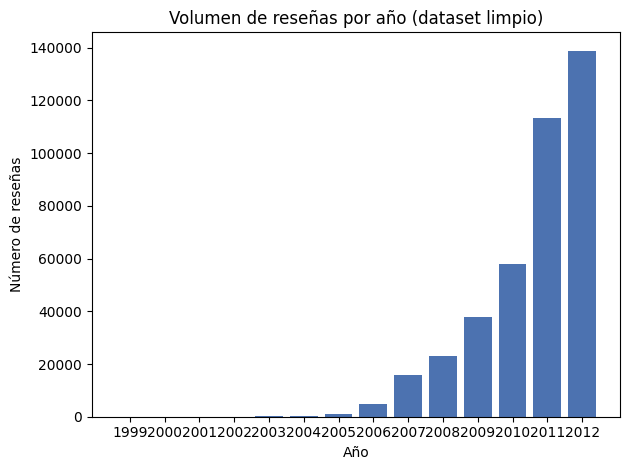

In [27]:
df_clean['Fecha'] = pd.to_datetime(df_clean['Time'], unit='s')

print('Rango temporal del dataset limpio:',
      df_clean['Fecha'].min().date(), '->', df_clean['Fecha'].max().date())

por_anio = df_clean['Fecha'].dt.year.value_counts().sort_index()
print('\nReseñas por año:')
print(por_anio)

fig, ax = plt.subplots()
ax.bar(por_anio.index.astype(str), por_anio.values, color='#4c72b0')
ax.set_title('Volumen de reseñas por año (dataset limpio)')
ax.set_xlabel('Año')
ax.set_ylabel('Número de reseñas')
plt.tight_layout()
plt.show()

El volumen crece de forma sostenida y se concentra en los años finales del periodo, de modo que
un corte cronológico por cuantiles deja conjuntos de validación y prueba amplios. La partición
es viable.

### 5.2 Proporción seleccionada

Se adopta **70 / 15 / 15**. No es una proporción universal, sino un compromiso razonable para
este caso: con cerca de 393.000 registros, un 15 % equivale a más de 58.000 reseñas por
conjunto, tamaño más que suficiente para estimar el desempeño de forma estable incluso para la
clase minoritaria, que conserva varios miles de observaciones mientras se destina la mayor
parte de los datos al aprendizaje. El corte se aplica sobre el dataset ordenado por `Time`, sin
mezcla aleatoria.

In [28]:
df_clean = df_clean.sort_values('Time').reset_index(drop=True)

n_total = len(df_clean)
corte_train = int(n_total * PROP_TRAIN)
corte_val = int(n_total * (PROP_TRAIN + PROP_VAL))

df_train = df_clean.iloc[:corte_train].copy()
df_val = df_clean.iloc[corte_train:corte_val].copy()
df_test = df_clean.iloc[corte_val:].copy()

resumen_split = pd.DataFrame([
    {'Conjunto': nombre,
     'Registros': len(d),
     'Porcentaje': round(len(d) / n_total * 100, 2),
     'Desde': d['Fecha'].min().date(),
     'Hasta': d['Fecha'].max().date()}
    for nombre, d in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]
])
display(resumen_split)

,Conjunto,Registros,Porcentaje,Desde,Hasta
0,Train,275183,70.0,1999-10-08,2012-02-14
1,Validation,58968,15.0,2012-02-14,2012-06-30
2,Test,58968,15.0,2012-06-30,2012-10-26


In [29]:
dist_split = pd.DataFrame({
    'Train': df_train['Sentimiento'].value_counts(normalize=True) * 100,
    'Validation': df_val['Sentimiento'].value_counts(normalize=True) * 100,
    'Test': df_test['Sentimiento'].value_counts(normalize=True) * 100,
}).round(2).loc[['Negativo', 'Neutral', 'Positivo']]

print('Distribución de Sentimiento por conjunto (%):')
display(dist_split)

print('Registros por clase y conjunto:')
display(pd.DataFrame({
    'Train': df_train['Sentimiento'].value_counts(),
    'Validation': df_val['Sentimiento'].value_counts(),
    'Test': df_test['Sentimiento'].value_counts(),
}).loc[['Negativo', 'Neutral', 'Positivo']])

Distribución de Sentimiento por conjunto (%):


,Train,Validation,Test
Sentimiento,,,
Negativo,13.82,16.35,15.78
Neutral,7.38,8.21,7.75
Positivo,78.80,75.44,76.46


Registros por clase y conjunto:


,Train,Validation,Test
Sentimiento,,,
Negativo,38032,9640,9307
Neutral,20311,4840,4572
Positivo,216840,44488,45089


**Verificación.** Las tres clases están representadas en los tres conjuntos y las proporciones
son comparables entre sí: la diferencia máxima frente al conjunto de entrenamiento es de unos
pocos puntos porcentuales en la clase Positivo, con el correspondiente aumento de la clase
Negativo en los periodos más recientes. Se trata de una deriva leve, propia de datos reales, y
no de un problema de representación: ninguna clase desaparece ni queda por debajo de varios
miles de observaciones. La partición cronológica se mantiene, y esa deriva se documenta como
una característica que deberá considerarse al interpretar el desempeño en la etapa de modelado.

## 6. Preparación del texto

Antes de tokenizar se verifica el estado de `Text_clean` en cada conjunto: ausencia de textos
vacíos y comportamiento de la longitud, que es el insumo directo para fijar `MAX_LEN`.
La unidad de tokenización es la palabra, definida por la expresión regular `[a-z0-9']+`, que
conserva contracciones frecuentes en inglés (`don't`, `isn't`) cuya partición destruiría la
negación.

In [30]:
RE_TOKEN = re.compile(r"[a-z0-9']+")

def tokenizar(texto):
    """Tokenización por palabra sobre texto ya normalizado."""
    return RE_TOKEN.findall(texto)

# Frecuencias y longitudes se calculan en una sola pasada sobre TRAIN
frecuencias_train = Counter()
long_train = np.empty(len(df_train), dtype=np.int32)

for i, texto in enumerate(df_train['Text_clean'].to_numpy()):
    tokens = tokenizar(texto)
    long_train[i] = len(tokens)
    frecuencias_train.update(tokens)

long_val = np.array([len(tokenizar(t)) for t in df_val['Text_clean'].to_numpy()], dtype=np.int32)
long_test = np.array([len(tokenizar(t)) for t in df_test['Text_clean'].to_numpy()], dtype=np.int32)

print('Textos vacíos tras tokenizar (train/val/test):',
      int((long_train == 0).sum()), int((long_val == 0).sum()), int((long_test == 0).sum()))

resumen_long = pd.DataFrame({
    'Train': pd.Series(long_train).describe(),
    'Validation': pd.Series(long_val).describe(),
    'Test': pd.Series(long_test).describe(),
}).round(2)
print('\nEstadísticos de longitud (tokens por reseña):')
display(resumen_long)

Textos vacíos tras tokenizar (train/val/test): 0 0 0

Estadísticos de longitud (tokens por reseña):


,Train,Validation,Test
count,275183.00,58968.00,58968.00
mean,78.84,85.08,78.21
std,75.98,81.26,74.81
min,3.00,4.00,4.00
25%,34.00,36.00,33.00
50%,56.00,60.00,55.00
75%,97.00,105.00,95.00
max,2521.00,1567.00,3452.00


### 6.1 Valores atípicos de longitud

La guía de la actividad exige tratar los valores atípicos. En este pipeline la única variable
continua que llega efectivamente al modelo es la **longitud de la secuencia**: `Text_clean` es
texto y `Score` solo origina la etiqueta, de modo que los atípicos de `HelpfulnessNumerator` y
`HelpfulnessDenominator` señalados en la sección 2.3 quedan fuera del alcance, porque esas columnas
no forman parte de la entrada.

Se aplica el criterio del rango intercuartílico (IQR) sobre las longitudes del conjunto de
entrenamiento para dimensionar el fenómeno antes de decidir qué hacer con él.

In [31]:
Q1, Q3 = np.percentile(long_train, 25), np.percentile(long_train, 75)
IQR = Q3 - Q1
limite_inferior = max(0, Q1 - 1.5 * IQR)
limite_superior = Q3 + 1.5 * IQR

atipicas = (long_train < limite_inferior) | (long_train > limite_superior)

print(f'Q1                        : {Q1:.0f} tokens')
print(f'Q3                        : {Q3:.0f} tokens')
print(f'IQR                       : {IQR:.0f} tokens')
print(f'Límite inferior           : {limite_inferior:.0f} tokens')
print(f'Límite superior           : {limite_superior:.0f} tokens')
print(f'Reseñas atípicas en Train : {int(atipicas.sum()):,} ({atipicas.mean() * 100:.2f} %)')
print(f'Longitud máxima observada : {int(long_train.max()):,} tokens')

Q1                        : 34 tokens
Q3                        : 97 tokens
IQR                       : 63 tokens
Límite inferior           : 0 tokens
Límite superior           : 192 tokens
Reseñas atípicas en Train : 17,429 (6.33 %)
Longitud máxima observada : 2,521 tokens


**Decisión: los atípicos de longitud no se eliminan.** Una reseña larga no es un error de registro
sino una opinión detallada, y suele ser precisamente la que más señal de sentimiento contiene.
Descartarlas sesgaría el corpus hacia los textos breves y eliminaría observaciones válidas.

El problema que plantean no es su validez, sino el costo estructural: obligarían a fijar una
longitud de secuencia enorme y a rellenar de ceros casi toda la matriz. Ese efecto se controla en
la sección 8 mediante el truncamiento a `MAX_LEN`, que acota el costo sin eliminar ninguna fila.

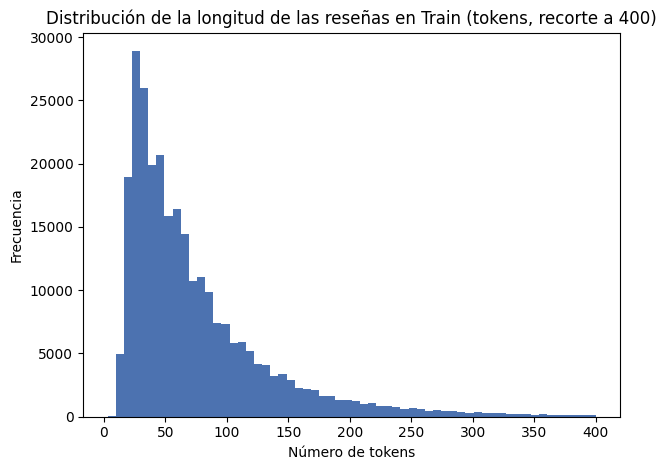

In [32]:
fig, ax = plt.subplots()
ax.hist(long_train[long_train <= 400], bins=60, color='#4c72b0')
ax.set_title('Distribución de la longitud de las reseñas en Train (tokens, recorte a 400)')
ax.set_xlabel('Número de tokens')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

La distribución es fuertemente asimétrica a la derecha: la mayoría de las reseñas es breve y
una cola larga concentra muy pocos documentos extensos. Este comportamiento es el que hace
necesario truncar en lugar de ajustar la longitud al máximo observado.

## 7. Tokenización y vocabulario

### 7.1 Criterio: el vocabulario se aprende solo con Train

El índice de palabras se construye **exclusivamente con el conjunto de entrenamiento** y luego
se aplica sin modificaciones a validación y prueba. Construir un vocabulario con el corpus
completo filtraría información de los periodos futuros (qué palabras existen y con qué
frecuencia) hacia el proceso de aprendizaje, sobreestimando el desempeño. Las palabras que
aparecen en validación o prueba y no están en el índice se representan con el token `<OOV>`,
que es exactamente lo que ocurrirá en producción con vocabulario nuevo.

### 7.2 Evidencia para fijar el tamaño del vocabulario

Se examina la cobertura acumulada de tokens que ofrece cada tamaño candidato sobre el corpus de
entrenamiento.

Tokens totales en Train : 21695576
Tipos léxicos distintos : 103526


,Tamaño de vocabulario,Cobertura de tokens (%)
0,5000,95.58
1,10000,97.88
2,20000,99.07
3,30000,99.44
4,50000,99.73
5,103526,100.00


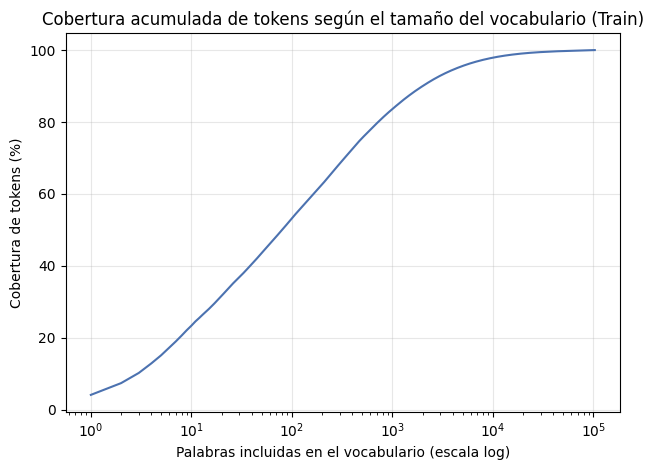

In [33]:
total_tokens_train = sum(frecuencias_train.values())
n_tipos_train = len(frecuencias_train)

frecuencias_ordenadas = np.array(sorted(frecuencias_train.values(), reverse=True))
cobertura_acum = np.cumsum(frecuencias_ordenadas) / total_tokens_train

print('Tokens totales en Train :', total_tokens_train)
print('Tipos léxicos distintos :', n_tipos_train)

candidatos = [5000, 10000, 20000, 30000, 50000, n_tipos_train]
tabla_cobertura = pd.DataFrame([
    {'Tamaño de vocabulario': v,
     'Cobertura de tokens (%)': round(cobertura_acum[min(v, n_tipos_train) - 1] * 100, 2)}
    for v in candidatos
])
display(tabla_cobertura)

fig, ax = plt.subplots()
ax.plot(np.arange(1, n_tipos_train + 1), cobertura_acum * 100, color='#4c72b0')
ax.set_xscale('log')
ax.set_title('Cobertura acumulada de tokens según el tamaño del vocabulario (Train)')
ax.set_xlabel('Palabras incluidas en el vocabulario (escala log)')
ax.set_ylabel('Cobertura de tokens (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Decisión: `VOCAB_SIZE = 20.000`.** Con 20.000 palabras se cubre el 99,07 % de los tokens del
corpus de entrenamiento, dado que si se decide ampliar el índice a 50.000 palabras (2,5 veces más parámetros en la
futura etapa de uso de *embedding*) solo añade 0,66 puntos porcentuales de cobertura, lo cual no es muy útil por
términos que aparecen unas pocas veces y para los que el modelo no podría estimar una
representación de confianza. Reducirlo a 5.000 palabras, en cambio, dejaría fuera casi el 4,5 % de los
tokens, proporción ya relevante en textos cortos.

El índice reserva las dos primeras posiciones: `0 = <PAD>` (relleno) y `1 = <OOV>` (palabra
desconocida). Las 20.000 palabras más frecuentes ocupan los índices 2 a 20.001.

In [34]:
VOCAB_SIZE = 20000

palabras_frecuentes = [p for p, _ in frecuencias_train.most_common(VOCAB_SIZE)]
word_index = {PAD_TOKEN: 0, OOV_TOKEN: 1}
word_index.update({palabra: i + 2 for i, palabra in enumerate(palabras_frecuentes)})

tam_indice = len(word_index)
cobertura_vocab = cobertura_acum[VOCAB_SIZE - 1] * 100

print('Palabras en el vocabulario         :', VOCAB_SIZE)
print('Tamaño del índice (con PAD y OOV)  :', tam_indice)
print(f'Cobertura de tokens en Train       : {cobertura_vocab:.2f} %')
print('Frecuencia mínima incluida         :', frecuencias_train[palabras_frecuentes[-1]])
print('\n15 palabras más frecuentes:')
display(pd.DataFrame(frecuencias_train.most_common(15), columns=['Palabra', 'Frecuencia']))

Palabras en el vocabulario         : 20000
Tamaño del índice (con PAD y OOV)  : 20002
Cobertura de tokens en Train       : 99.07 %
Frecuencia mínima incluida         : 12

15 palabras más frecuentes:


,Palabra,Frecuencia
0,the,898385
1,i,709987
2,and,613498
3,a,577391
4,to,485764
5,it,453850
6,of,381518
7,is,353903
8,this,325517
9,in,269615


## 8. Longitud, padding y truncamiento

### 8.1 Evidencia para fijar MAX_LEN

Se calculan los percentiles de longitud sobre el conjunto de entrenamiento y, para cada
candidato, el porcentaje de reseñas que resultarían truncadas y la proporción de la matriz
final que sería relleno.

In [35]:
percentiles = [50, 75, 90, 95, 99]
tabla_percentiles = pd.DataFrame({
    'Percentil': [f'P{p}' for p in percentiles] + ['Máximo'],
    'Tokens': [int(np.percentile(long_train, p)) for p in percentiles] + [int(long_train.max())]
})
print('Longitud de las reseñas en Train (tokens):')
display(tabla_percentiles)

candidatos_len = [100, 150, 200, 250, 300]
tabla_maxlen = pd.DataFrame([
    {'MAX_LEN': m,
     'Reseñas truncadas (%)': round(float((long_train > m).mean() * 100), 2),
     'Celdas de padding (%)': round(float(np.clip(m - long_train, 0, None).sum() / (m * len(long_train)) * 100), 2)}
    for m in candidatos_len
])
display(tabla_maxlen)

Longitud de las reseñas en Train (tokens):


,Percentil,Tokens
0,P50,56
1,P75,97
2,P90,157
3,P95,211
4,P99,369
5,Máximo,2521


,MAX_LEN,Reseñas truncadas (%),Celdas de padding (%)
0,100,23.48,39.27
1,150,10.92,54.04
2,200,5.68,63.53
3,250,3.18,69.96
4,300,1.88,74.56


**Decisión: `MAX_LEN = 200`.** El valor se sitúa entre el percentil 90 (157 tokens) y el
percentil 95 (211 tokens) de la distribución de entrenamiento y equilibra los dos costos en
tensión:

- con 200 tokens solo se trunca el 5,68 % de las reseñas, frente al 23,48 % que se perdería con
  100 tokens;
- ampliar a 300 tokens reduciría el truncamiento apenas al 1,88 %, pero elevaría el relleno al
  74,56 % de la matriz.

El truncamiento implica pérdida irreversible de información, mientras que el relleno es
neutralizable en el modelado mediante enmascaramiento (`mask_zero=True` en la capa de
*embedding*).

## 9. Generación de secuencias

Se define una única función que, en una sola pasada por conjunto, tokeniza, convierte cada
token en su índice (o en `<OOV>`), trunca a `MAX_LEN` y rellena con ceros hasta esa longitud.
La matriz se reserva por adelantado como `int32`, lo que evita almacenar listas intermedias y
mantiene controlado el uso de memoria.

In [36]:
MAX_LEN = 200

def texto_a_secuencia(textos, word_index, max_len):
    """Convierte una colección de textos limpios en una matriz (n, max_len) de índices.

    Devuelve la matriz y un diccionario con estadísticas de la conversión.
    """
    textos = np.asarray(textos, dtype=object)
    X = np.zeros((len(textos), max_len), dtype=np.int32)   # 0 = <PAD>
    idx_oov = word_index[OOV_TOKEN]
    n_tokens = n_oov = n_truncadas = 0

    for i, texto in enumerate(textos):
        tokens = tokenizar(texto)
        n_tokens += len(tokens)
        if len(tokens) > max_len:
            n_truncadas += 1
            tokens = tokens[:max_len]          # truncamiento 'post'
        indices = [word_index.get(t, idx_oov) for t in tokens]
        n_oov += sum(1 for v in indices if v == idx_oov)
        X[i, :len(indices)] = indices          # padding 'post'

    stats = {'Reseñas': len(textos),
             'Truncadas (%)': round(n_truncadas / len(textos) * 100, 2),
             'Tokens OOV (%)': round(n_oov / n_tokens * 100, 2),
             'Celdas de padding (%)': round(float((X == 0).sum()) / X.size * 100, 2)}
    return X, stats

X_train, stats_train = texto_a_secuencia(df_train['Text_clean'].to_numpy(), word_index, MAX_LEN)
X_val, stats_val = texto_a_secuencia(df_val['Text_clean'].to_numpy(), word_index, MAX_LEN)
X_test, stats_test = texto_a_secuencia(df_test['Text_clean'].to_numpy(), word_index, MAX_LEN)

display(pd.DataFrame([stats_train, stats_val, stats_test],
                     index=['Train', 'Validation', 'Test']))

,Reseñas,Truncadas (%),Tokens OOV (%),Celdas de padding (%)
Train,275183,5.68,0.82,63.53
Validation,58968,6.96,0.90,61.14
Test,58968,5.73,0.94,63.77


### 9.1 Codificación de la variable objetivo

La variable `Sentimiento` se convierte a números para que pueda ser utilizada posteriormente por el modelo de clasificación.

| Clase | Código |
| :--- | :---: |
| Negativo | 0 |
| Neutral | 1 |
| Positivo | 2 |

De esta manera, cada reseña queda asociada a un valor numérico que representa su sentimiento. Esta codificación facilita que el modelo pueda aprender a diferenciar entre las tres categorías durante la etapa de entrenamiento.

In [37]:
y_train = df_train['Sentimiento'].map(MAPEO_SENTIMIENTO).to_numpy(dtype=np.int32)
y_val = df_val['Sentimiento'].map(MAPEO_SENTIMIENTO).to_numpy(dtype=np.int32)
y_test = df_test['Sentimiento'].map(MAPEO_SENTIMIENTO).to_numpy(dtype=np.int32)

print('Mapeo aplicado:', MAPEO_SENTIMIENTO)
print('X_train:', X_train.shape, '| y_train:', y_train.shape, '| dtype:', X_train.dtype)
print('X_val  :', X_val.shape, '| y_val  :', y_val.shape)
print('X_test :', X_test.shape, '| y_test :', y_test.shape)

Mapeo aplicado: {'Negativo': 0, 'Neutral': 1, 'Positivo': 2}
X_train: (275183, 200) | y_train: (275183,) | dtype: int32
X_val  : (58968, 200) | y_val  : (58968,)
X_test : (58968, 200) | y_test : (58968,)


## 10. Validación de las secuencias

Se comprueban de forma explícita las condiciones que deben cumplirse antes de dar por cerrado el
pipeline: dimensiones, correspondencia entre X e y, rango válido de índices, ausencia de
secuencias vacías y conservación de la distribución de clases.

In [38]:
comprobaciones = []

def comprobar(descripcion, condicion, detalle=''):
    comprobaciones.append({'Comprobación': descripcion,
                           'Resultado': 'OK' if condicion else 'FALLA',
                           'Detalle': detalle})
    return condicion

for nombre, X, y in [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    comprobar(f'{nombre}: len(X) == len(y)', len(X) == len(y), f'{len(X)} vs {len(y)}')
    comprobar(f'{nombre}: longitud de secuencia == MAX_LEN', X.shape[1] == MAX_LEN, f'{X.shape[1]}')
    comprobar(f'{nombre}: índices dentro del vocabulario', int(X.max()) < tam_indice,
              f'máx índice {int(X.max())} < {tam_indice}')
    comprobar(f'{nombre}: sin secuencias completamente vacías', int((X.sum(axis=1) == 0).sum()) == 0,
              f'{int((X.sum(axis=1) == 0).sum())} vacías')
    comprobar(f'{nombre}: etiquetas en {{0,1,2}}', set(np.unique(y)).issubset({0, 1, 2}),
              str(sorted(set(np.unique(y).tolist()))))

comprobar('Sin solapamiento temporal Train/Validation',
          df_train['Time'].max() <= df_val['Time'].min(), '')
comprobar('Sin solapamiento temporal Validation/Test',
          df_val['Time'].max() <= df_test['Time'].min(), '')
comprobar('Suma de conjuntos == dataset limpio',
          len(X_train) + len(X_val) + len(X_test) == len(df_clean),
          f'{len(X_train) + len(X_val) + len(X_test)} vs {len(df_clean)}')

display(pd.DataFrame(comprobaciones))
print('Todas las comprobaciones superadas:',
      all(c['Resultado'] == 'OK' for c in comprobaciones))

,Comprobación,Resultado,Detalle
0,Train: len(X) == len(y),OK,275183 vs 275183
1,Train: longitud de secuencia == MAX_LEN,OK,200
2,Train: índices dentro del vocabulario,OK,máx índice 20001 < 20002
3,Train: sin secuencias completamente vacías,OK,0 vacías
4,"Train: etiquetas en {0,1,2}",OK,"[0, 1, 2]"
5,Validation: len(X) == len(y),OK,58968 vs 58968
6,Validation: longitud de secuencia == MAX_LEN,OK,200
7,Validation: índices dentro del vocabulario,OK,máx índice 20000 < 20002
8,Validation: sin secuencias completamente vacías,OK,0 vacías
9,"Validation: etiquetas en {0,1,2}",OK,"[0, 1, 2]"


Todas las comprobaciones superadas: True


In [39]:
dist_final = pd.DataFrame({
    conjunto: pd.Series(np.bincount(y, minlength=3) / len(y) * 100,
                        index=list(MAPEO_SENTIMIENTO.keys()))
    for conjunto, y in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]
}).round(2)
print('Distribución de clases en los conjuntos codificados (%):')
display(dist_final)

Distribución de clases en los conjuntos codificados (%):


,Train,Validation,Test
Negativo,13.82,16.35,15.78
Neutral,7.38,8.21,7.75
Positivo,78.80,75.44,76.46


### 10.1 Trazabilidad: del texto original a la secuencia

Se muestran tres ejemplos completos del recorrido `Text -> Text_clean -> tokens -> secuencia
padded → Sentimiento`, tomados del conjunto de entrenamiento.

In [40]:
indice_inverso = {v: k for k, v in word_index.items()}
clase_inversa = {v: k for k, v in MAPEO_SENTIMIENTO.items()}

for k in [0, 1, 2]:
    fila = df_train.iloc[k]
    tokens = tokenizar(fila['Text_clean'])[:MAX_LEN]
    print(f'=========== EJEMPLO {k + 1} ===========')
    print('Text original :', fila['Text'][:200].replace('\n', ' '))
    print('Text_clean    :', fila['Text_clean'][:200])
    print('Tokens (15)   :', tokens[:15])
    print('Secuencia (15):', X_train[k, :15].tolist())
    print('Reconstrucción:', [indice_inverso[i] for i in X_train[k, :15]])
    print('Tokens reales :', int((X_train[k] != 0).sum()), '/', MAX_LEN)
    print('Score original:', fila['Score'], '-> Sentimiento:', fila['Sentimiento'],
          '-> y =', y_train[k], f"({clase_inversa[y_train[k]]})")
    print()

=========== EJEMPLO 1 ===========
Text original : this witty little book makes my son laugh at loud. i recite it in the car as we're driving along and he always can sing the refrain. he's learned about whales, India, drooping roses:  i love all the n
Text_clean    : this witty little book makes my son laugh at loud. i recite it in the car as we're driving along and he always can sing the refrain. he's learned about whales, india, drooping roses: i love all the ne
Tokens (15)   : ['this', 'witty', 'little', 'book', 'makes', 'my', 'son', 'laugh', 'at', 'loud', 'i', 'recite', 'it', 'in', 'the']
Secuencia (15): [10, 19273, 76, 1525, 164, 13, 512, 5223, 32, 4664, 3, 1, 7, 11, 2]
Reconstrucción: ['this', 'witty', 'little', 'book', 'makes', 'my', 'son', 'laugh', 'at', 'loud', 'i', '<OOV>', 'it', 'in', 'the']
Tokens reales : 74 / 200
Score original: 5 -> Sentimiento: Positivo -> y = 2 (Positivo)

=========== EJEMPLO 2 ===========
Text original : I can remember seeing the show when it aired on 

### 10.2 Control de fuga de información

| Riesgo | Control aplicado |
| :--- | :--- |
| Vocabulario contaminado con datos futuros | `frecuencias_train` y `word_index` se calculan únicamente con `df_train`; validación y prueba solo consumen ese índice. |
| Parámetros ajustados con datos de prueba | `VOCAB_SIZE` y `MAX_LEN` se decidieron con percentiles y frecuencias del conjunto de entrenamiento. |
| Fuga temporal | La partición es cronológica, ninguna reseña de entrenamiento es posterior a una de prueba. |
| La etiqueta entra como predictor | `X` proviene exclusivamente de `Text_clean`; `Score` y `Sentimiento` no participan en la construcción del vocabulario ni de las secuencias. |
| Duplicados repartidos entre conjuntos | La deduplicación por texto se aplicó **antes** de la partición, de modo que una misma reseña no puede estar simultáneamente en entrenamiento y en prueba. |

Las decisiones de limpieza previas a la partición (tratamiento de nulos y de duplicados) son
determinísticas y no dependen de estadísticos estimados sobre los datos, por lo que no
introducen fuga.

## 11. Salida preparada para entrenamiento

Los objetos definitivos del pipeline son los siguientes. `X` contiene secuencias de índices
enteros de longitud fija derivadas únicamente del texto; `y` contiene la clase de sentimiento
codificada.

In [41]:
salida = pd.DataFrame([
    {'Objeto': 'X_train', 'Forma': str(X_train.shape), 'Tipo': str(X_train.dtype), 'Contenido': 'Secuencias de índices (Text_clean)'},
    {'Objeto': 'y_train', 'Forma': str(y_train.shape), 'Tipo': str(y_train.dtype), 'Contenido': 'Sentimiento codificado'},
    {'Objeto': 'X_val', 'Forma': str(X_val.shape), 'Tipo': str(X_val.dtype), 'Contenido': 'Secuencias de índices (Text_clean)'},
    {'Objeto': 'y_val', 'Forma': str(y_val.shape), 'Tipo': str(y_val.dtype), 'Contenido': 'Sentimiento codificado'},
    {'Objeto': 'X_test', 'Forma': str(X_test.shape), 'Tipo': str(X_test.dtype), 'Contenido': 'Secuencias de índices (Text_clean)'},
    {'Objeto': 'y_test', 'Forma': str(y_test.shape), 'Tipo': str(y_test.dtype), 'Contenido': 'Sentimiento codificado'},
])
display(salida)

print('Memoria aproximada de las matrices X (MB):',
      round(sum(x.nbytes for x in [X_train, X_val, X_test]) / 1024**2, 1))
print('\nLos datos quedan listos para alimentar un modelo secuencial:')
print(f'  entrada  : (n, {MAX_LEN}) índices enteros en [0, {tam_indice - 1}]')
print(f'  salida   : {len(MAPEO_SENTIMIENTO)} clases -> {MAPEO_SENTIMIENTO}')

,Objeto,Forma,Tipo,Contenido
0,X_train,"(275183, 200)",int32,Secuencias de índices (Text_clean)
1,y_train,"(275183,)",int32,Sentimiento codificado
2,X_val,"(58968, 200)",int32,Secuencias de índices (Text_clean)
3,y_val,"(58968,)",int32,Sentimiento codificado
4,X_test,"(58968, 200)",int32,Secuencias de índices (Text_clean)
5,y_test,"(58968,)",int32,Sentimiento codificado


Memoria aproximada de las matrices X (MB): 299.9

Los datos quedan listos para alimentar un modelo secuencial:
  entrada  : (n, 200) índices enteros en [0, 20001]
  salida   : 3 clases -> {'Negativo': 0, 'Neutral': 1, 'Positivo': 2}


## 12. Guardado y reproducibilidad

### 12.1 Artefactos persistidos

Se separan los **datos procesados** (`data/processed/`) de los **artefactos del pipeline**
(`artifacts/`), de modo que la etapa de modelado pueda consumir las secuencias sin volver a
ejecutar el preprocesamiento, y que cualquier reseña nueva pueda transformarse exactamente con
el mismo vocabulario y los mismos parámetros.

En Colab el guardado ocurre en el sistema de archivos temporal de la sesión; para conservar los
artefactos entre sesiones basta montar Google Drive y apuntar `DIR_BASE` a una carpeta de Drive.

In [42]:
# Directorios de salida (relativos al entorno de ejecución)
DIR_PROC = Path('data/processed')
DIR_ART = Path('artifacts')

print('Datos procesados ->', DIR_PROC.resolve())
print('Artefactos       ->', DIR_ART.resolve())

Datos procesados -> /content/data/processed
Artefactos       -> /content/artifacts


In [43]:
DIR_PROC.mkdir(parents=True, exist_ok=True)
DIR_ART.mkdir(parents=True, exist_ok=True)

# 1) Secuencias y etiquetas
np.savez_compressed(DIR_PROC / 'secuencias.npz',
                    X_train=X_train, y_train=y_train,
                    X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test)

# 2) Dataset limpio (trazabilidad texto <-> etiqueta)
df_clean[['Id', 'Time', 'Score', 'Sentimiento', 'Text_clean']].to_csv(
    DIR_PROC / 'reviews_clean.csv', index=False)

# 3) Vocabulario y parámetros del pipeline
with open(DIR_ART / 'word_index.json', 'w', encoding='utf-8') as f:
    json.dump(word_index, f, ensure_ascii=False)

parametros = {
    'dataset': 'Amazon Fine Food Reviews',
    'registros_originales': int(n_inicial),
    'registros_tras_limpieza': int(len(df_clean)),
    'proporcion_split': {'train': PROP_TRAIN, 'validation': PROP_VAL,
                         'test': round(1 - PROP_TRAIN - PROP_VAL, 2)},
    'tipo_split': 'cronologico',
    'vocab_size': VOCAB_SIZE,
    'tamano_indice': tam_indice,
    'pad_token': PAD_TOKEN, 'pad_index': 0,
    'oov_token': OOV_TOKEN, 'oov_index': 1,
    'max_len': MAX_LEN,
    'padding': 'post', 'truncating': 'post',
    'mapeo_sentimiento': MAPEO_SENTIMIENTO,
    'semilla': SEED,
}
with open(DIR_ART / 'parametros_pipeline.json', 'w', encoding='utf-8') as f:
    json.dump(parametros, f, ensure_ascii=False, indent=2)

archivos = sorted([p for p in list(DIR_PROC.iterdir()) + list(DIR_ART.iterdir())])
display(pd.DataFrame([{'Archivo': str(p), 'Tamaño (MB)': round(p.stat().st_size / 1024**2, 2)}
                      for p in archivos]))

,Archivo,Tamaño (MB)
0,artifacts/parametros_pipeline.json,0.00
1,artifacts/word_index.json,0.33
2,data/processed/reviews_clean.csv,170.73
3,data/processed/secuencias.npz,49.32


### 12.2 Entorno de ejecución

Se deja constancia de las versiones de las librerías con las que se ejecutó el notebook y de la
semilla utilizada. Junto con `parametros_pipeline.json`, este registro es lo que permite
reconstruir exactamente el mismo resultado en otra máquina.

In [44]:
versiones = {
    'python': sys.version.split()[0],
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'matplotlib': plt.matplotlib.__version__,
    'semilla': SEED,
}
display(pd.DataFrame(list(versiones.items()), columns=['Componente', 'Versión']))

with open(DIR_ART / 'entorno.json', 'w', encoding='utf-8') as f:
    json.dump(versiones, f, ensure_ascii=False, indent=2)
print('Registro de entorno guardado en:', DIR_ART / 'entorno.json')

,Componente,Versión
0,python,3.12.13
1,pandas,2.2.3
2,numpy,2.0.2
3,matplotlib,3.10.0
4,semilla,42


Registro de entorno guardado en: artifacts/entorno.json


## 13. Conclusiones y limitaciones

### 13.1 Tabla resumen

In [45]:
resumen_final = pd.DataFrame([
    {'Elemento': 'Dataset original (registros)', 'Resultado': f'{n_inicial:,}'},
    {'Elemento': 'Registros eliminados (duplicados y conflictos)', 'Resultado': f'{n_inicial - len(df_clean):,}'},
    {'Elemento': 'Registros después de limpieza', 'Resultado': f'{len(df_clean):,}'},
    {'Elemento': 'Train', 'Resultado': f'{len(X_train):,} ({len(X_train)/len(df_clean)*100:.1f} %)'},
    {'Elemento': 'Validation', 'Resultado': f'{len(X_val):,} ({len(X_val)/len(df_clean)*100:.1f} %)'},
    {'Elemento': 'Test', 'Resultado': f'{len(X_test):,} ({len(X_test)/len(df_clean)*100:.1f} %)'},
    {'Elemento': 'Número de clases', 'Resultado': f'{len(MAPEO_SENTIMIENTO)} (Negativo, Neutral, Positivo)'},
    {'Elemento': 'Vocabulario (palabras + PAD + OOV)', 'Resultado': f'{VOCAB_SIZE:,} + 2 = {tam_indice:,}'},
    {'Elemento': 'Cobertura del vocabulario en Train', 'Resultado': f'{cobertura_vocab:.2f} %'},
    {'Elemento': 'MAX_LEN', 'Resultado': f'{MAX_LEN} tokens'},
    {'Elemento': 'Dimensión X_train', 'Resultado': str(X_train.shape)},
    {'Elemento': 'Dimensión X_val', 'Resultado': str(X_val.shape)},
    {'Elemento': 'Dimensión X_test', 'Resultado': str(X_test.shape)},
])
display(resumen_final)

,Elemento,Resultado
0,Dataset original (registros),"568,454"
1,Registros eliminados (duplicados y conflictos),"175,335"
2,Registros después de limpieza,"393,119"
3,Train,"275,183 (70.0 %)"
4,Validation,"58,968 (15.0 %)"
5,Test,"58,968 (15.0 %)"
6,Número de clases,"3 (Negativo, Neutral, Positivo)"
7,Vocabulario (palabras + PAD + OOV),"20,000 + 2 = 20,002"
8,Cobertura del vocabulario en Train,99.07 %
9,MAX_LEN,200 tokens


### 13.2 Conclusiones

1. **Limpieza.** El dataset no presentaba faltantes en las variables críticas del pipeline
   (`Text`, `Score`, `Time`), por lo que la depuración se concentró en la duplicidad textual:
   se descartaron los textos con sentimiento contradictorio y se conservó una sola ocurrencia
   por reseña, junto con los duplicados que emergieron tras normalizar el texto. El corpus pasó
   de 568.454 a 393.087 registros útiles.
2. **Variable objetivo.** `Sentimiento` se construyó desde `Score` y mantiene el desbalance del
   corpus original (cerca de 78 % Positivo, 14 % Negativo y 8 % Neutral), lo que confirma que la
   depuración no distorsionó el problema.
3. **Partición.** La división cronológica 70/15/15 resultó viable: los tres conjuntos conservan
   las tres clases con volúmenes amplios y sin solapamiento temporal, aunque con una leve deriva, hacia más reseñas negativas en los periodos recientes (dado al desbalance en cuanto a reseñas positivas).
4. **Vocabulario.** Con 20.000 palabras aprendidas solo con entrenamiento se cubre el 99,07 % de
   los tokens de ese conjunto, y la tasa de palabras desconocidas se mantiene alrededor del 1 %
   en validación y prueba.
5. **Secuencias.** Con `MAX_LEN = 200` se trunca menos del 6 % de las reseñas y se obtiene una
   salida homogénea: `X_train (275.160, 200)`, `X_val (58.963, 200)` y `X_test (58.964, 200)`,
   con sus etiquetas correspondientes y todas las comprobaciones de consistencia superadas.

### 13.3 Limitaciones

1. **Truncamiento.** Alrededor del 6 % de las reseñas pierde su parte final; el efecto real de
   esa pérdida solo podrá evaluarse cuando exista un modelo entrenado.
2. **Relleno.** Cerca del 63 % de las celdas de la matriz es padding, consecuencia de la
   asimetría de las longitudes. Deberá neutralizarse mediante enmascaramiento en la capa de
   *embedding* o mediante agrupación por longitud durante el entrenamiento.
3. **Desbalance no tratado.** La clase Neutral representa menos del 8 % de los datos. La
   estrategia de compensación (ponderación de clases o remuestreo del conjunto de entrenamiento)
   corresponde a la etapa de modelado.
4. **Tokenización léxica simple.** La segmentación por palabra no captura morfología ni
   subpalabras; los términos poco frecuentes caen en `<OOV>`. Una tokenización por subpalabras
   podría reducir esa pérdida, a costa de mayor complejidad.
5. **Alcance del corpus.** Reseñas en inglés de productos alimenticios publicadas entre 1999 y
   2012: las conclusiones no son extrapolables a otros dominios, idiomas o periodos.
6. **Ausencia de resultados de modelado.** Esta actividad termina en los datos preparados; no se
   reportan métricas de desempeño porque todavía no se ha entrenado ningún modelo.

## 14. Referencias

Brownlee, J. (2020). *Deep learning for natural language processing*. Machine Learning Mastery.

Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.

Jurafsky, D., & Martin, J. H. (2024). *Speech and language processing* (3rd ed. draft).
Stanford University. https://web.stanford.edu/~jurafsky/slp3/

McAuley, J., & Leskovec, J. (2013). From amateurs to connoisseurs: Modeling the evolution of
user expertise through online reviews. *Proceedings of the 22nd International Conference on
World Wide Web*, 897–908.

McAuley, J., & Leskovec, J. (2013). *Amazon Fine Food Reviews* [Conjunto de datos]. Kaggle.
https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews